Saving downloaded_images.zip to downloaded_images.zip
Unzipped to ./knee_images/
Running on device: cuda
Total images found: 1650
Class distribution: Counter({0: 514, 1: 477, 2: 232, 3: 221, 4: 206})
Computed Class Weights: [0.642023346303502, 0.6918238993710691, 1.4224137931034482, 1.493212669683258, 1.6019417475728155]
Data Split -> Train: 1056, Val: 264, Test: 330
Loading EfficientNet-B5...
Downloading: "https://download.pytorch.org/models/efficientnet_b5_lukemelas-1a07897c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b5_lukemelas-1a07897c.pth


100%|██████████| 117M/117M [00:04<00:00, 27.1MB/s]


Loading ResNet18...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 155MB/s]



Starting Training for 40 epochs...
Epoch 1/40 | Train Loss: 1.5970 Acc: 0.3494 | Val Loss: 1.3134 Acc: 0.5455
  -> Best model saved!
Epoch 2/40 | Train Loss: 1.3757 Acc: 0.4934 | Val Loss: 1.2698 Acc: 0.5871
  -> Best model saved!
Epoch 3/40 | Train Loss: 1.2858 Acc: 0.5322 | Val Loss: 1.0739 Acc: 0.7045
  -> Best model saved!
Epoch 4/40 | Train Loss: 1.2221 Acc: 0.5625 | Val Loss: 1.0518 Acc: 0.7197
  -> Best model saved!
Epoch 5/40 | Train Loss: 1.1181 Acc: 0.6364 | Val Loss: 0.9955 Acc: 0.7197
  -> Best model saved!
Epoch 6/40 | Train Loss: 1.0630 Acc: 0.6752 | Val Loss: 0.9763 Acc: 0.7576
  -> Best model saved!
Epoch 7/40 | Train Loss: 1.0217 Acc: 0.6875 | Val Loss: 0.9349 Acc: 0.7462
  -> Best model saved!
Epoch 8/40 | Train Loss: 0.9960 Acc: 0.7102 | Val Loss: 0.9454 Acc: 0.7348
Epoch 9/40 | Train Loss: 0.9654 Acc: 0.7415 | Val Loss: 0.9278 Acc: 0.7424
  -> Best model saved!
Epoch 10/40 | Train Loss: 0.9174 Acc: 0.7566 | Val Loss: 0.9538 Acc: 0.7424
Epoch 11/40 | Train Loss: 0.9

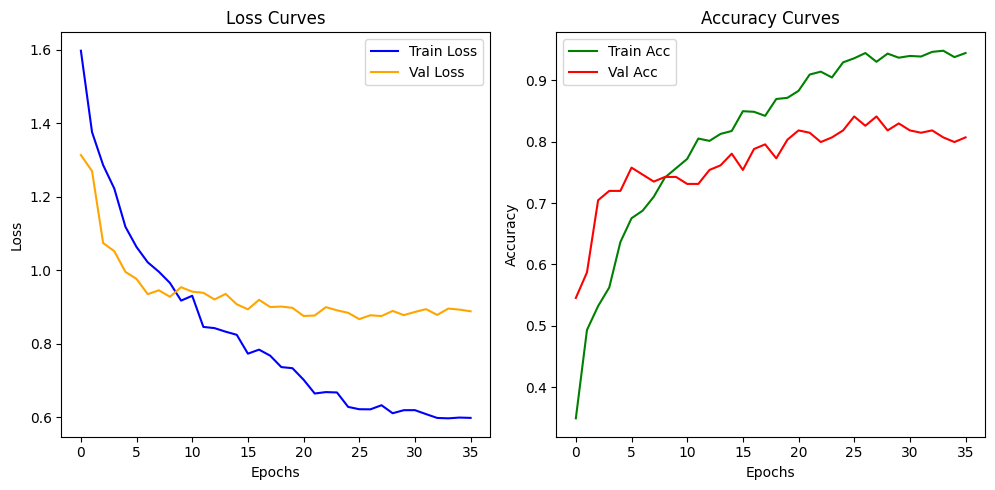


Generating Evaluation Metrics (Confusion Matrix, ROC)...


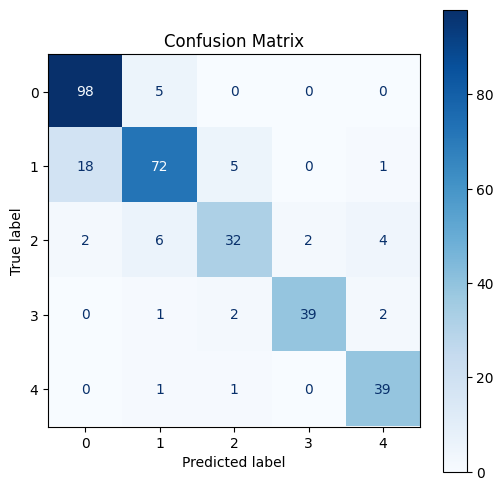

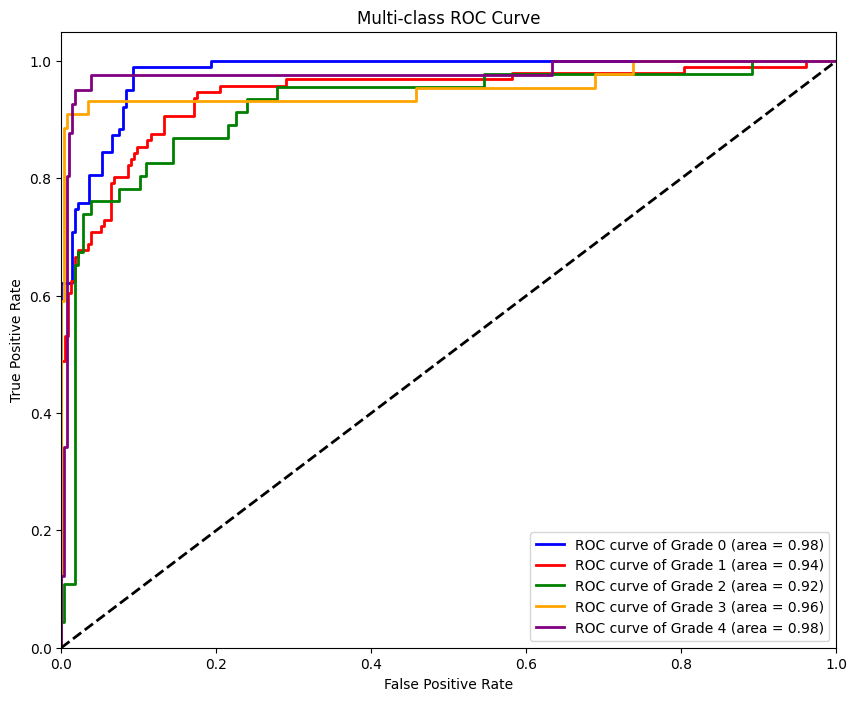


   CONTINUOUS INFERENCE MODE

[INFO] Please upload an X-ray image to test (or Cancel upload to stop).


Saving 3.png to 3.png

Processing 3.png...


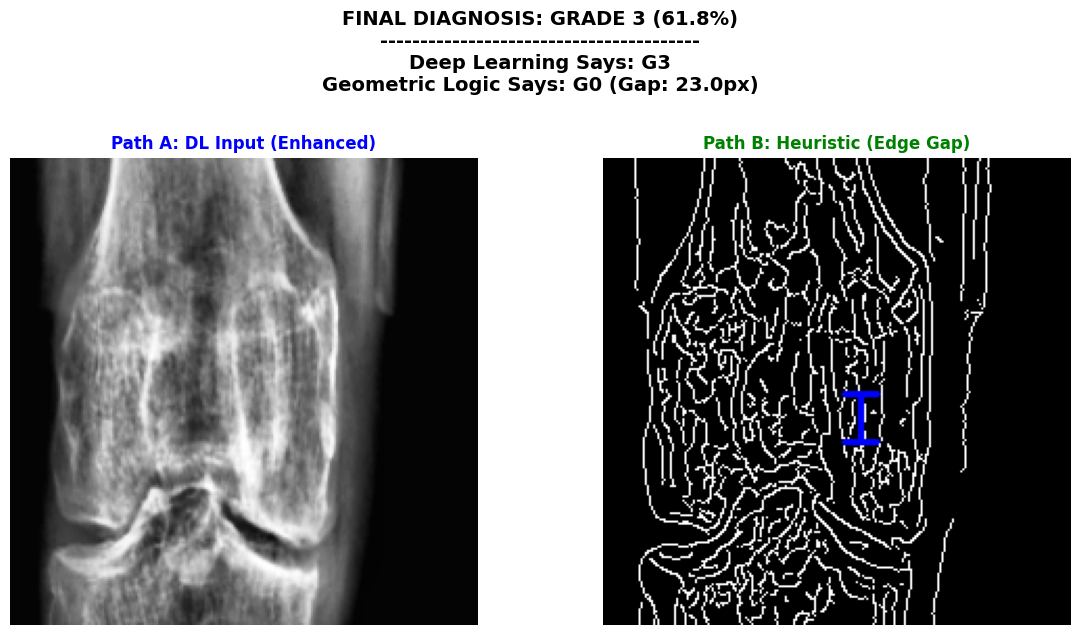


[INFO] Please upload an X-ray image to test (or Cancel upload to stop).


Saving 1.png to 1.png

Processing 1.png...


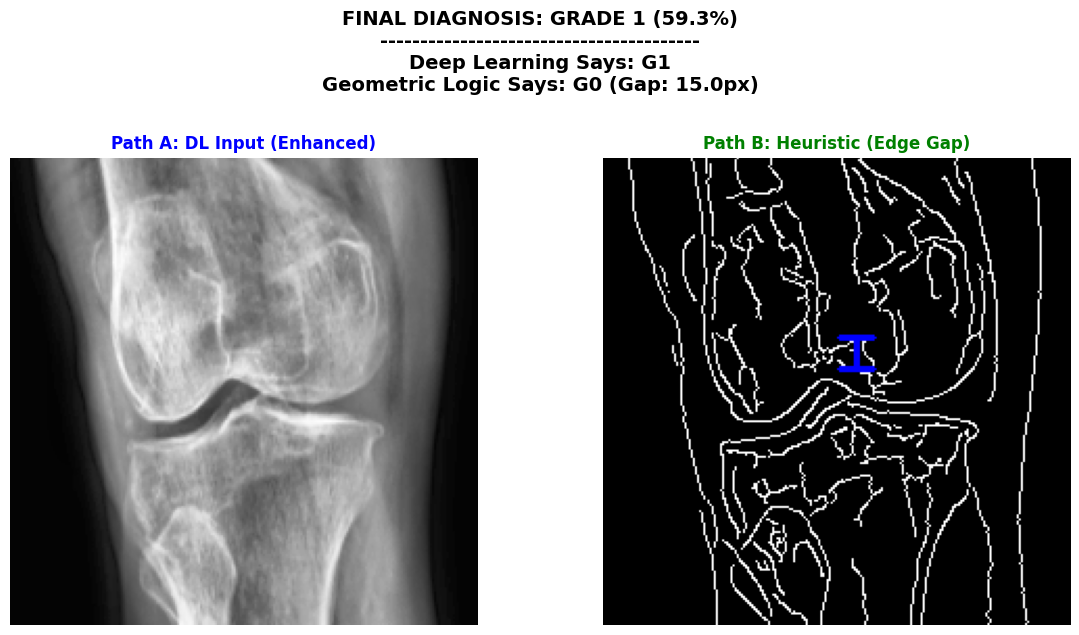


[INFO] Please upload an X-ray image to test (or Cancel upload to stop).



Inference stopped by user.


In [ ]:


import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import copy

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from google.colab import files
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]
!unzip -q "{zip_name}" -d knee_images
print("Unzipped to ./knee_images/")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")

# Enhanced Configuration for Ensemble Model
BATCH_SIZE = 6
NUM_EPOCHS = 40  # Increased to 40 as requested
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-3
DROPOUT_RATE = 0.5
PATIENCE = 10    # Increased patience for longer training cycles


data_dir = 'knee_images'

if not os.path.exists(data_dir):
    print(f"Directory '{data_dir}' not found. Please unzip dataset first.")
    file_paths, labels = [], []
else:
    file_paths, labels = [], []
    for label in sorted(os.listdir(data_dir)):
        class_dir = os.path.join(data_dir, label)
        if not os.path.isdir(class_dir):
            continue
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_paths.append(os.path.join(class_dir, fname))
                try:
                    labels.append(int(label))
                except ValueError:
                    continue

print(f"Total images found: {len(file_paths)}")
count_dict = Counter(labels)
print(f"Class distribution: {count_dict}")

# Class Weighting
if len(labels) > 0:
    class_counts = [count_dict[i] for i in range(5)]
    total_samples = sum(class_counts)
    class_weights = [total_samples / (5 * c) if c > 0 else 1.0 for c in class_counts]
    class_weights_tensor = torch.FloatTensor(class_weights).to(device)
    print(f"Computed Class Weights: {class_weights}")
else:
    class_weights_tensor = None

if len(file_paths) == 0:
    print("WARNING: No images found. Skipping split.")
    train_paths, val_paths, test_paths = [], [], []
    train_labels, val_labels, test_labels = [], [], []
else:
    train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
        file_paths, labels, test_size=0.20, stratify=labels, random_state=42
    )
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        train_val_paths, train_val_labels, test_size=0.20, stratify=train_val_labels, random_state=42
    )
    print(f"Data Split -> Train: {len(train_paths)}, Val: {len(val_paths)}, Test: {len(test_paths)}")



def preprocess_image_cv2(image_path):
    """
    Returns (Edge Map, Enhanced Grayscale)
    """
    img = cv2.imread(image_path)
    if img is None: raise ValueError(f"Failed to load: {image_path}")

    # Resize to standard input size
    img = cv2.resize(img, (224, 224))

    # 1. Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Enhancement (CLAHE) - Applied FIRST
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)

    # 3. Edges (for Heuristic)
    # Stronger Gaussian Blur to ignore texture and find only bone outlines
    blur = cv2.GaussianBlur(enhanced, (7, 7), 0)

    # Lower Thresholds for Canny to catch edges in low contrast
    edges = cv2.Canny(blur, 20, 80)

    # Convert to 3-channel
    enhanced_bgr = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2BGR)
    edges_bgr = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)

    return edges_bgr, enhanced_bgr

class KneeOADataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        edges, enhanced = preprocess_image_cv2(self.paths[idx])
        img_for_dl = enhanced

        if self.transform:
            img_tensor = self.transform(img_for_dl)
        else:
            img_tensor = transforms.functional.to_tensor(img_for_dl)

        label = self.labels[idx]
        return img_tensor, label

train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_ds = KneeOADataset(train_paths, train_labels, transform=train_transforms)
val_ds   = KneeOADataset(val_paths,   val_labels,   transform=val_transforms)
test_ds  = KneeOADataset(test_paths,  test_labels,  transform=val_transforms)

if len(train_paths) > 0:
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
else:
    train_loader = None


class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        out = avg_out + max_out
        return self.sigmoid(out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv1(x)
        return self.sigmoid(x)

class CBAM(nn.Module):
    def __init__(self, in_planes, ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.ca = ChannelAttention(in_planes, ratio)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

class EnsembleKnee(nn.Module):
    def __init__(self, num_classes=5):
        super(EnsembleKnee, self).__init__()
        print("Loading EfficientNet-B5...")
        self.effnet = models.efficientnet_b5(weights='DEFAULT')
        self.eff_features = self.effnet.classifier[1].in_features
        self.effnet.classifier = nn.Identity()
        self.eff_attention = CBAM(self.eff_features)

        print("Loading ResNet18...")
        self.resnet = models.resnet18(weights='DEFAULT')
        self.res_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Identity()
        self.res_attention = CBAM(self.res_features)

        self.total_features = self.eff_features + self.res_features

        self.classifier = nn.Sequential(
            nn.Dropout(p=DROPOUT_RATE),
            nn.Linear(self.total_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(p=DROPOUT_RATE),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # EfficientNet
        x1 = self.effnet.features(x)
        x1 = self.effnet.avgpool(x1)
        x1 = self.eff_attention(x1)
        x1 = torch.flatten(x1, 1)

        # ResNet
        x2 = self.resnet.conv1(x)
        x2 = self.resnet.bn1(x2)
        x2 = self.resnet.relu(x2)
        x2 = self.resnet.maxpool(x2)
        x2 = self.resnet.layer1(x2)
        x2 = self.resnet.layer2(x2)
        x2 = self.resnet.layer3(x2)
        x2 = self.resnet.layer4(x2)
        x2 = self.resnet.avgpool(x2)
        x2 = self.res_attention(x2)
        x2 = torch.flatten(x2, 1)

        combined = torch.cat((x1, x2), dim=1)
        out = self.classifier(combined)
        return out

model = EnsembleKnee(num_classes=5)
model = model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# ---------------------------------------------------------
# 5. TRAINING LOOP
# ---------------------------------------------------------
train_losses, train_accs = [], []
val_losses,   val_accs   = [], []

best_val_loss = float('inf')
epochs_no_improve = 0
best_model_wts = copy.deepcopy(model.state_dict())

if train_loader:
    print(f"\nStarting Training for {NUM_EPOCHS} epochs...")

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / len(train_ds)
        epoch_acc  = correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        model.eval()
        running_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss = running_loss / len(val_ds)
        val_acc  = correct / total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        scheduler.step(val_loss)

        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), 'best_knee_ensemble_cbam.pth')
            epochs_no_improve = 0
            print("  -> Best model saved!")
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

    print(f"\nBest Validation Loss: {best_val_loss:.4f}")
    model.load_state_dict(best_model_wts)

    # --- METRICS & PLOTS ---
    print("\nGenerating Detailed Training Graphs...")
    plt.figure(figsize=(15, 5))

    # 1. Loss
    plt.subplot(1, 3, 1)
    plt.plot(train_losses, label='Train Loss', color='blue')
    plt.plot(val_losses, label='Val Loss', color='orange')
    plt.title('Loss Curves')
    plt.xlabel('Epochs'); plt.ylabel('Loss')
    plt.legend()

    # 2. Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(train_accs, label='Train Acc', color='green')
    plt.plot(val_accs, label='Val Acc', color='red')
    plt.title('Accuracy Curves')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # --- EVALUATION: CONFUSION MATRIX & ROC CURVES ---
    print("\nGenerating Evaluation Metrics (Confusion Matrix, ROC)...")
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    eval_loader = test_loader if test_loader else val_loader
    if eval_loader:
        with torch.no_grad():
            for inputs, labels in eval_loader:
                inputs = inputs.to(device)
                outputs = model(inputs)
                probs = F.softmax(outputs, dim=1) # Get probabilities for ROC
                _, preds = torch.max(outputs, 1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())
                all_probs.extend(probs.cpu().numpy())

        # Confusion Matrix
        cm = confusion_matrix(all_labels, all_preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
        plt.figure(figsize=(6, 6))
        disp.plot(cmap=plt.cm.Blues, values_format='d', ax=plt.gca())
        plt.title('Confusion Matrix')
        plt.show()

        # ROC Curves
        n_classes = 5
        y_test_bin = label_binarize(all_labels, classes=[0, 1, 2, 3, 4])
        all_probs = np.array(all_probs)

        fpr = dict()
        tpr = dict()
        roc_auc = dict()

        plt.figure(figsize=(10, 8))
        colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])

        for i, color in zip(range(n_classes), colors):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
            plt.plot(fpr[i], tpr[i], color=color, lw=2,
                     label=f'ROC curve of Grade {i} (area = {roc_auc[i]:.2f})')

        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Multi-class ROC Curve')
        plt.legend(loc="lower right")
        plt.show()


def measure_gap(edges_gray):
    h, w = edges_gray.shape
    # Focus on center box
    y_start, y_end = int(h * 0.35), int(h * 0.65)
    x_start, x_end = int(w * 0.40), int(w * 0.60)

    gaps = []
    gap_coords = []

    for x in range(x_start, x_end, 2):
        col = edges_gray[y_start:y_end, x]
        edge_indices = np.where(col > 0)[0] + y_start
        if len(edge_indices) < 2: continue
        diffs = np.diff(edge_indices)
        max_idx = np.argmax(diffs)
        gap_size = diffs[max_idx]
        if 2 < gap_size < (h * 0.3):
            gaps.append(gap_size)
            gap_coords.append( (edge_indices[max_idx], edge_indices[max_idx+1], x) )

    if not gaps: return 0, (0, 0, w//2)
    median_gap = np.median(gaps)
    best_idx = np.argmin(np.abs(np.array(gaps) - median_gap))
    return median_gap, gap_coords[best_idx]

def annotate_and_predict(image_path):
    # Get both versions: One for Heuristic (Edges), One for DL (Enhanced Gray)
    img_bgr_edges, img_bgr_enhanced = preprocess_image_cv2(image_path)

    # --- Path B: Heuristic ---
    edges_gray = cv2.cvtColor(img_bgr_edges, cv2.COLOR_BGR2GRAY)
    gap, (y1, y2, xcol) = measure_gap(edges_gray)

    max_expected_gap = 18.0
    gap_score = 0.01 + (min(gap, max_expected_gap) / max_expected_gap) * (99.99 - 0.01)

    if gap_score < 15: h_grade = 4
    elif gap_score < 30: h_grade = 3
    elif gap_score < 50: h_grade = 2
    elif gap_score < 70: h_grade = 1
    else: h_grade = 0

    # --- Path A: Deep Learning ---
    img_tensor = val_transforms(img_bgr_enhanced).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(img_tensor)
        dl_probs = F.softmax(logits, dim=1).cpu().numpy()[0]

    # --- Fusion ---
    heuristic_probs = np.zeros(5)
    heuristic_probs[h_grade] = 1.0
    alpha = 0.7
    fused_probs = (alpha * dl_probs) + ((1 - alpha) * heuristic_probs)
    final_grade = np.argmax(fused_probs)
    confidence = fused_probs[final_grade]

    # --- Visualization (Heuristic Path) ---
    ann_heuristic = img_bgr_edges.copy()
    if gap > 0:
        cv2.line(ann_heuristic, (xcol, y1), (xcol, y2), (255, 0, 0), 2)
        cv2.line(ann_heuristic, (xcol - 8, y1), (xcol + 8, y1), (255, 0, 0), 2)
        cv2.line(ann_heuristic, (xcol - 8, y2), (xcol + 8, y2), (255, 0, 0), 2)

    # Return: Enhanced Input (DL view), Annotated Edges (Heuristic view), Stats
    return cv2.cvtColor(img_bgr_enhanced, cv2.COLOR_BGR2RGB), \
           cv2.cvtColor(ann_heuristic, cv2.COLOR_BGR2RGB), \
           {
               'final_grade': final_grade,
               'dl_grade': np.argmax(dl_probs),
               'heu_grade': h_grade,
               'gap_score': gap_score,
               'confidence': confidence,
               'pixel_gap': gap
           }


print("\n" + "="*50)
print("   CONTINUOUS INFERENCE MODE")
print("="*50)

while True:
    try:
        from google.colab import files
        print("\n[INFO] Please upload an X-ray image to test (or Cancel upload to stop).")
        uploaded = files.upload()

        if not uploaded:
            print("No file uploaded. Stopping inference loop.")
            break

        for fn in uploaded.keys():
            print(f'\nProcessing {fn}...')
            try:
                # Get results
                dl_view, heu_view, res = annotate_and_predict(fn)

                # Plot Side-by-Side
                fig, axs = plt.subplots(1, 2, figsize=(12, 6))

                # 1. Deep Learning View
                axs[0].imshow(dl_view, cmap='gray')
                axs[0].set_title("Path A: DL Input (Enhanced)", color='blue', fontweight='bold')
                axs[0].axis('off')

                # 2. Heuristic View
                axs[1].imshow(heu_view)
                axs[1].set_title("Path B: Heuristic (Edge Gap)", color='green', fontweight='bold')
                axs[1].axis('off')

                # Main Title with Results
                result_text = (f"FINAL DIAGNOSIS: GRADE {res['final_grade']} ({res['confidence']:.1%})\n"
                               f"----------------------------------------\n"
                               f"Deep Learning Says: G{res['dl_grade']}\n"
                               f"Geometric Logic Says: G{res['heu_grade']} (Gap: {res['pixel_gap']:.1f}px)")

                plt.suptitle(result_text, fontsize=14, fontweight='bold', y=1.05)
                plt.tight_layout()
                plt.show()

            except Exception as e:
                print(f"Error processing {fn}: {e}")

    except ImportError:
        print("Google Colab files module not found. Inference loop disabled.")
        break
    except KeyboardInterrupt:
        print("\nInference stopped by user.")
        break